In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import scipy.io
import cv2
import os
import scipy as sp
import pandas as pd
from skimage import io, morphology
from skimage.morphology import disk, square, reconstruction, binary_opening, binary_closing, opening
from skimage.exposure import rescale_intensity

In [2]:
# All the path 
projet_path = os.getcwd()
image_path = os.path.join(projet_path, "Lame_criblee")
mask_path = os.path.join(projet_path, "Terrain")
result_path = os.path.join(projet_path, "Results", "Jupyter")

In [3]:
# Open image 
im_name = "LC001"
if os.path.exists(os.path.join(image_path, f"{im_name}.jpg")): 
    im = cv2.imread(f'{image_path}/{im_name}.jpg')
elif os.path.exists(os.path.join(image_path, f"{im_name}.png")):
    im = cv2.imread(f'{image_path}/{im_name}.png')
else : 
    print("The file path does not exist")
[H, W, I] = im.shape
#plt.imshow(im)
im = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

In [4]:
# Open the mask : Charger le .mat
mat = scipy.io.loadmat(f'Terrain/{im_name}_VT.mat')
# Récupérer juste la matrice et la mettre dnas la varibale mask (car binaire)
mask = mat['seeds']
#plt.imshow(mask, cmap=plt.cm.gray)

In [5]:
# Overlap image and mask
colormap = colors.ListedColormap(['white', 'red'])
#plt.imshow(im, cmap=plt.cm.gray)
#plt.imshow(mask, cmap = colormap, alpha = 0.2)

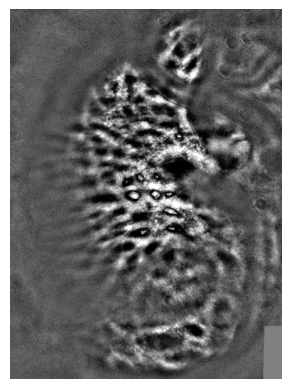

In [6]:
# Cleaning the dark rectangles
_, binary = cv2.threshold(im, 10, 255, cv2.THRESH_BINARY_INV)
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
created_mask = np.ones(im.shape, dtype=np.uint8) * 255

for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    if (w > 20 and h > 20) and (x < 10 or x + w > im.shape[1] - 10):
        cv2.drawContours(created_mask, [contour], -1, 0, -1)

im[created_mask == 0] = 128
plt.imshow(im, cmap = plt.cm.gray)
plt.axis('off')
plt.savefig(os.path.join(result_path, "Rectangle_free.jpg"), bbox_inches='tight')

In [7]:
# Define the quantifications to determine which image is better
def quantification(im, mask):
    false_positives = np.sum((im == 1) & (mask == 0))
    false_negatives = np.sum((im == 0) & (mask == 1))
    true_positives = np.sum((im == 1) & (mask == 1))
    true_negatives = np.sum((im == 0) & (mask == 0))
    false_positives += np.sum((im == 255) & (mask == 0))
    false_negatives += np.sum((im == 0) & (mask == 255))
    true_positives += np.sum((im == 255) & (mask == 255))
    true_negatives += np.sum((im == 0) & (mask == 0))
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return false_positives, false_negatives, true_positives, true_negatives, precision, recall, f1_score

In [8]:
columns = ['Filter', 'precision', 'rappel', 'f1_score']
df = pd.DataFrame(columns = columns)
def name_exists(df, name):
    return (df['Filter'] == name).any()

In [9]:
def ReconstructionDilatation(F, IC, SE):
    """
    Parameters:
    F (ndarray): Marker image
    IC (ndarray): Mask image (complement of original image)
    SE (ndarray): Structuring element
    """
    prev_F = np.zeros_like(F)
    while not np.array_equal(F, prev_F):
        prev_F = F.copy()
        F = cv2.dilate(F, SE)
        F = np.minimum(F, IC)
    return F

In [10]:
# Fill the holes in the white structures 
def fillHoles(im):
    im = (im > 0).astype(np.uint8)

    # Dimensions of the source image
    H, W = im.shape

    # Structuring element
    SE = np.ones((3, 3), np.uint8)

    # Create the marker image F
    F = np.zeros((H, W), dtype=np.uint8)
    F[:, 0] = 1 - im[:, 0]
    F[:, -1] = 1 - im[:, -1]
    F[0, :] = 1 - im[0, :]
    F[-1, :] = 1 - im[-1, :]

    IC = 1 - im
    HC = ReconstructionDilatation(F, IC, SE)
    H = 1 - HC
    return H


In [11]:
# Inverser couleurs images
im_inverted = cv2.bitwise_not(im)
# plt.imshow(im_inverted, cmap = plt.cm.gray)

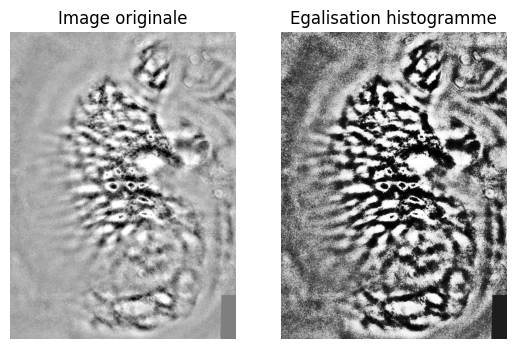

In [12]:
# Egalisation de l'histogramme de niveaux de gris
egal_image = cv2.equalizeHist(im_inverted)    
fig, axes = plt.subplots(1, 2)
axes[0].imshow(im_inverted, cmap = plt.cm.gray)
axes[0].set_title('Image originale')
axes[1].imshow(egal_image, cmap = plt.cm.gray)
axes[1].set_title('Egalisation histogramme')
for ax in axes:
    ax.axis('off')

In [14]:
# Augmenter le contrast des images
contrast_coeff = 1.6
brightness_coeff = 0 #coeff entre 1 et 3 (en dessous de 1, diminue le contrast)
brighter_image = egal_image*contrast_coeff+brightness_coeff
brighter_image = np.clip(brighter_image, 0, 255)  # Limit values to the range [0, 255]
# fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# axes[0].imshow(egal_image, cmap='gray')
# axes[0].set_title('Original Image')
# axes[1].imshow(brighter_image, cmap='gray')
# axes[1].set_title('Adjusted Image')

In [ ]:
# Put a threshold on the image 
name = 'Threshold_im'
blur_factor = 5
blur_im = cv2.GaussianBlur(egal_image,(blur_factor,blur_factor),0)
thresh = 230
_, seuil_im = cv2.threshold(blur_im, thresh, 255, cv2.THRESH_BINARY_INV)
seuil_im = cv2.bitwise_not(seuil_im)
filled_seuil_im = fillHoles(seuil_im)

fig, axes = plt.subplots(1, 2)
axes[0].imshow(seuil_im, cmap = plt.cm.gray)
axes[0].set_title(f'Image seuillée à {thresh}')
axes[1].imshow(filled_seuil_im, cmap = plt.cm.gray)
axes[1].set_title(f'Image seuillée à {thresh} et rebouchée')
for ax in axes:
    ax.axis('off')
    
FP, FN, TP, TN, precision, recall, f1_score = quantification(seuil_im, mask)
if name_exists(df, name):
    df.drop(df[df['Filter'] == name].index, inplace = True)
data = [name, precision, recall, f1_score]
df.loc[len(df.index)] = data
print(df)
plt.savefig(os.path.join(result_path, f"{name}.jpg"), bbox_inches='tight')

In [ ]:
# Fill the missing spots inside the white structures and delete noise
name = 'Open_Close_im'
SE7 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(7,7))
SE9 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(9,9))
SE11 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(11,11))

opening3 = cv2.morphologyEx(egal_image, cv2.MORPH_OPEN, SE7)
closing3 = cv2.morphologyEx(opening3, cv2.MORPH_CLOSE, SE9)
ret, close_seuil_im = cv2.threshold(closing3, 230, 255, cv2.THRESH_BINARY_INV)
close_seuil_im = cv2.bitwise_not(close_seuil_im)
filled_close_seuil_im = fillHoles(close_seuil_im)

fig, axes = plt.subplots(1, 2)
axes[0].imshow(filled_close_seuil_im, cmap = plt.cm.gray)
axes[0].set_title('Filled Closing + Thresh Image')
axes[1].imshow(mask, cmap = plt.cm.gray)
axes[1].set_title('Mask')
for ax in axes:
    ax.axis('off')
    
FP, FN, TP, TN, precision, recall, f1_score = quantification(close_seuil_im, mask*255)
if name_exists(df, name):
    df.drop(df[df['Filter'] == name].index, inplace = True)
data = [name, precision, recall, f1_score]
df.loc[len(df.index)] = data
print(df)
plt.savefig(os.path.join(result_path, f"{name}.jpg"), bbox_inches='tight')

In [ ]:
name = 'Top_hat_im'
k = 30
change = True
init_tophat = filled_seuil_im

while change : 
    k+=1
    SE = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(k,k))
    seuil_tophat_im = cv2.morphologyEx(seuil_im, cv2.MORPH_TOPHAT, SE)
    filled_seuil_tophat_im = fillHoles(seuil_tophat_im)
    if np.array_equal(filled_seuil_tophat_im, init_tophat):
        change = False
    init_tophat = filled_seuil_tophat_im
print(k)

fig, axes = plt.subplots(1,2)
axes[0].imshow(init_tophat, cmap = plt.cm.gray)
axes[0].set_title('filled_seuil_tophat_im')
axes[1].imshow(mask, cmap = plt.cm.gray)
axes[1].set_title('Mask')
for ax in axes:
    ax.axis('off')
FP, FN, TP, TN, precision, recall, f1_score = quantification(filled_seuil_tophat_im, mask)
if name_exists(df, name):
    df.drop(df[df['Filter'] == name].index, inplace = True)
data = [name, precision, recall, f1_score]
df.loc[len(df.index)] = data                  
print(df)
plt.savefig(os.path.join(result_path, f"{name}.jpg"), bbox_inches='tight')

In [ ]:
# Filtres alternés séquentiels 
name = "FAS"
MAX_TAILLE = 3
tailles = range(1, MAX_TAILLE + 1)

SE = [disk(r) for r in tailles]
fas = filled_seuil_im.copy()

# Débruitage par FAS
for se in SE:
    openR = reconstruction(binary_opening(fas, se), fas)  # Ouverture par reconstruction
    fas = 1 - reconstruction(1 - binary_closing(openR, se), 1 - openR)  # Fermeture par reconstruction

fig, axes = plt.subplots(1,2)
axes[0].imshow(fas, cmap = plt.cm.gray)
axes[0].set_title("Débruitage par FAS")
axes[1].imshow(mask, cmap = plt.cm.gray)
axes[1].set_title('Mask')
for ax in axes:
    ax.axis('off')
FP, FN, TP, TN, precision, recall, f1_score = quantification(fas, mask)
if name_exists(df, name):
    df.drop(df[df['Filter'] == name].index, inplace = True)
data = [name, precision, recall, f1_score]
df.loc[len(df.index)] = data                  
print(df)
plt.savefig(os.path.join(result_path, f"{name}.jpg"), bbox_inches='tight')


In [ ]:
# Structuring element
name = "Fas_top_hat"
r = 50
se = disk(r)

# Top-hat transformation
im_open = opening(egal_image, se)
imTH = egal_image - im_open
imTH = rescale_intensity(imTH, out_range=(0, 255)).astype(np.uint8)

# Assuming fas is defined and loaded similarly to filled_seuil_im
# Replace 'fas' with your actual variable name
im_open_fas = opening(fas, se)
imFASTH = fas - im_open_fas
imFASTH = rescale_intensity(imFASTH, out_range=(0, 255)).astype(np.uint8)

# Display the results
fig, axes = plt.subplots(1,2)
axes[0].imshow(fas, cmap='gray')
axes[0].set_title("Original Image")
axes[1].imshow(imTH, cmap='gray')
axes[1].set_title(f'FAS (MAX TAILLE= {MAX_TAILLE}) + Top-hat avec r = {r}')
for ax in axes:
    ax.axis('off')
FP, FN, TP, TN, precision, recall, f1_score = quantification(imFASTH/255, mask)
if name_exists(df, name):
    df.drop(df[df['Filter'] == name].index, inplace = True)
data = [name, precision, recall, f1_score]
df.loc[len(df.index)] = data                  
print(df)
plt.tight_layout()
plt.savefig(os.path.join(result_path, "Processed_Image.jpg"), bbox_inches='tight')

In [ ]:
T = np.mean(im)
I = im < T
F = I.astype(np.uint8)
SE = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(k,k))
N = 2
for i in range(N):
    F = cv2.erode(F, SE)
im_reconstruc = ReconstructionDilatation(I, im_inverted.astype(np.uint8), SE)

In [ ]:
# Calcul du gradient 
grad_x = cv2.Sobel(egal_image, cv2.CV_64F, 1, 0, ksize=3)
grad_y = cv2.Sobel(egal_image, cv2.CV_64F, 0, 1, ksize=3)

gradient_magnitude = cv2.magnitude(grad_x, grad_y)
gradient_magnitude = cv2.normalize(gradient_magnitude, None, 0, 255, cv2.NORM_MINMAX)
plt.imshow(gradient_magnitude, cmap='gray')

In [ ]:
# edge detection 
edges = filled_seuil_im.copy()
shape_count = 0
total_area = 0
total_perimeter = 0
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for contour in contours:
    # Approximation du contour
    perimeter = cv2.arcLength(contour, True)
    epsilon = 0.01 * perimeter
    approx = cv2.approxPolyDP(contour, epsilon, True)
    
    M = cv2.moments(contour)
    if M["m00"] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
    else:
        cx, cy = 0, 0

    # Filtrer les formes en fonction de leurs caractéristiques
    area = cv2.contourArea(contour)
    if area > 100:  # Filtrer par taille
        shape_count += 1
        total_area += area
        total_perimeter +=perimeter
        cv2.drawContours(edges, [approx], -1, (255, 0, 0), 2)
        cv2.circle(edges, (cx, cy), 5, (255, 0, 0), -1)
mean_area = total_area / shape_count if shape_count > 0 else 0
mean_perimeter = total_perimeter / shape_count if shape_count > 0 else 0
print(shape_count, mean_area, mean_perimeter)
plt.imshow(edges, cmap=plt.cm.gray)
plt.axis('off')

In [ ]:
def imfilter(im,noyau):
    # Creation du bordage en miroir 
    h,w = np.shape(noyau)
    hbis = int(np.floor(h/2))
    wbis = int(np.floor(w/2))
    im_bis = np.pad(im, ((hbis,hbis),(wbis,wbis)),'symmetric')
    [Hbis,Wbis] = im_bis.shape
    # Delete le bordage 
    conv = sp.signal.convolve2d(im_bis, noyau)
    conv_bis = conv[hbis:Hbis-hbis, wbis:Wbis-wbis]
    return conv_bis

In [ ]:
# Filtre dérivatuer, passe haut, dessine les contours 
def passeHaut(im): 
    noyauhoriz = np.array([[-1, 0, 1]])
    noyauvert = np.array([[-1], [0], [1]])

    imhoriz = imfilter(im,noyauhoriz)
    imvert = imfilter(im,noyauvert)
    imcontour = np.sqrt(imhoriz**2 + imvert**2)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(im, cmap=plt.cm.gray)
    axes[1].imshow(imcontour, cmap=plt.cm.gray)

    return 
passeHaut(egal_image)

In [ ]:
# Noyau Lapalcien ou noyau dérivateur, fait apparaitre les coutours 
def laplacien(im, nb_voisins):
    if nb_voisins == 4 : 
        m_laplacien = [[0, -1, 0],
                   [-1, 4, -1],
                   [0, -1, 0]]
    elif nb_voisins == 8 : 
        m_laplacien = [[-1, -1, -1],
                   [-1, 8, -1],
                   [-1, -1, -1]]
    else : 
        return 0
    filtered_im = im*m_laplacien
    return filtered_im